In [1]:
# The purpose of this project is to:
# investigate the column density of mixing ratios 
# of 5 different cases ranging from e=0.0167 to e=0.4 for constant zero obliquity

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as ticker

In [2]:
# define eccentricity range

e_range =['e0','e01','e02','e03','e04']


# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0.001/atm/hist/')

# define specific path
          

Path_H2O        = []
Path_O3         = []

Path_ch4vmr     = []
Path_co2vmr     = []

Path_CLDHGH     = []


for i in range(len(data_dir_file)):
          
    Path_H2O.append(data_dir_file[i]+'H2O_'+ e_range[i] +'_obl0.nc')
    Path_O3.append(data_dir_file[i]+'O3_'+ e_range[i] +'_obl0.nc')
    Path_ch4vmr.append(data_dir_file[i]+'ch4vmr_'+ e_range[i] +'_obl0.nc')
    Path_co2vmr.append(data_dir_file[i]+'co2vmr_'+ e_range[i] +'_obl0.nc')
    Path_CLDHGH.append(data_dir_file[i]+'CLDHGH_'+ e_range[i] +'_obl0.nc')

# Import data

# each file has 5 case elements

H2O_obl0          =[]
O3_obl0           =[]
ch4vmr_obl0       =[]
co2vmr_obl0       =[]
CLDHGH_obl0       =[]


for i in range(len(e_range)):

          
    H2O_obl0.append(xr.open_mfdataset(Path_H2O[i]))
    O3_obl0.append(xr.open_mfdataset(Path_O3[i]))
    ch4vmr_obl0.append(xr.open_mfdataset(Path_ch4vmr[i]))
    co2vmr_obl0.append(xr.open_mfdataset(Path_co2vmr[i]))
    CLDHGH_obl0.append(xr.open_mfdataset(Path_CLDHGH[i]))
    
    




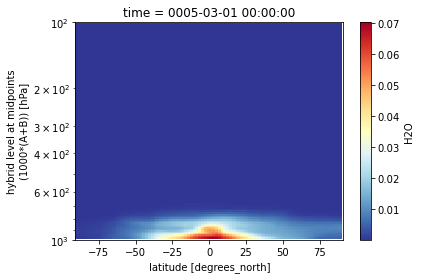

In [3]:
H2O_obl0[4].H2O.mean(dim='lon').isel(time=-1).plot.imshow(x='lat',cmap='RdYlBu_r',yscale='log',ylim=(1000, 100))

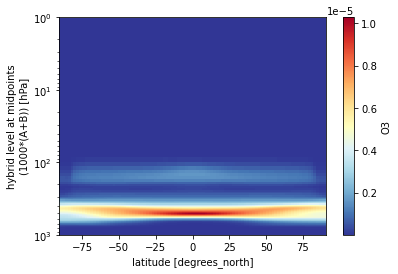

In [4]:
O3_obl0[4].O3.mean(dim='lon').mean(dim='time').plot.imshow(x='lat',cmap='RdYlBu_r',yscale='log',ylim=(1000, 1))

In [5]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0) #open the file

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    if (time == False):
        try:
            DS = DS.mean(dim='time')#take time mean
        except:
            print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

Text(0.5, 1.0, 'Ozone Mixing Ratios')

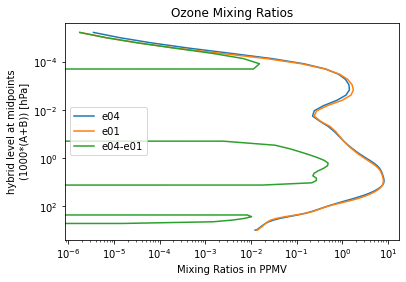

In [6]:
O3_e04_global=LatWeightAnyVar(O3_obl0[4].O3)*10**6
O3_e0_global=LatWeightAnyVar(O3_obl0[0].O3)*10**6

diff_O3=O3_e04_global-O3_e0_global

O3_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',yincrease=False)

O3_e0_global.plot(y='lev',yscale='log',xscale='log',label='e01',yincrease=False)

diff_O3.plot(y='lev',yscale='log',xscale='log',label='e04-e01',yincrease=False)

plt.legend()

plt.xlabel('Mixing Ratios in PPMV')

plt.title('Ozone Mixing Ratios')

In [7]:
O3_e04_global

<xarray.DataArray 'O3' (lev: 70)>
dask.array<mul, shape=(70,), dtype=float64, chunksize=(70,), chunktype=numpy.ndarray>
Coordinates:
  * lev      (lev) float64 5.96e-06 9.827e-06 1.62e-05 ... 957.5 976.3 992.6

In [8]:
#%% define latitudinal weighting function

def LatWeightAnyVar_timeframe(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=2)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

Text(0, 0.5, 'O3 mixing ratio in ppmv')

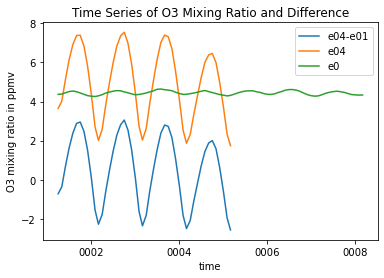

In [9]:
O3_e04_global_time=LatWeightAnyVar_timeframe(O3_obl0[4].O3)*10**6

O3_e0_global_time=LatWeightAnyVar_timeframe(O3_obl0[0].O3)*10**6

diff_O3_time=O3_e04_global_time-O3_e0_global_time

diff_O3_time.isel(lev=28).plot(label='e04-e01')

O3_e04_global_time.isel(lev=28).plot(label='e04')

O3_e0_global_time.isel(lev=28).plot(label='e0')


plt.legend()

plt.title('Time Series of O3 Mixing Ratio and Difference')

plt.ylabel('O3 mixing ratio in ppmv')

In [10]:
O3_e0_global_time.lev.isel(lev=28)

<xarray.DataArray 'lev' ()>
array(1.61285)
Coordinates:
    lev      float64 1.613
Attributes:
    long_name:      hybrid level at midpoints (1000*(A+B))
    units:          hPa
    positive:       down
    standard_name:  atmosphere_hybrid_sigma_pressure_coordinate
    formula_terms:  a: hyam b: hybm p0: P0 ps: PS

Text(0.5, 1.0, 'H2O Mixing Ratios')

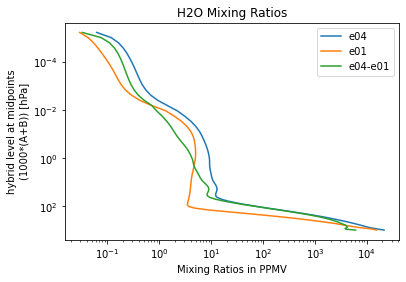

In [11]:
H2O_e04_global=LatWeightAnyVar(H2O_obl0[4].H2O)*10**6
H2O_e0_global=LatWeightAnyVar(H2O_obl0[0].H2O)*10**6

diff_H2O=H2O_e04_global-H2O_e0_global

H2O_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',yincrease=False)

H2O_e0_global.plot(y='lev',yscale='log',xscale='log',label='e01',yincrease=False)

diff_H2O.plot(y='lev',yscale='log',xscale='log',label='e04-e01',yincrease=False)
plt.legend()

plt.xlabel('Mixing Ratios in PPMV')

plt.title('H2O Mixing Ratios')

Text(0.5, 0, 'time in month')

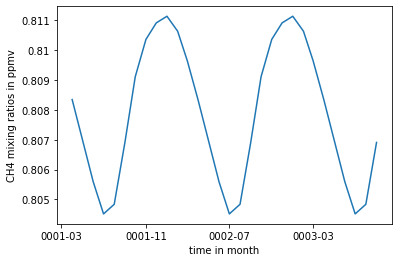

In [12]:
x=ch4vmr_obl0[3].ch4vmr.time
y=ch4vmr_obl0[3].ch4vmr.values

#################### how to make y unit ppmv with xarray.plot??????

fig, ax = plt.subplots()


# plot two identical plots
ax.plot(x, y)

scale_y = 1e6
ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*scale_y))
ax.yaxis.set_major_formatter(ticks_y)

ax.set_ylabel('CH4 mixing ratios in ppmv')
ax.set_xlabel('time in month')

# vertically integrated co2 mixing ratio in ppmv

Text(0.5, 0, 'time in month')

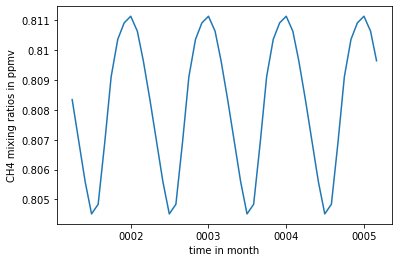

In [13]:
x=ch4vmr_obl0[4].ch4vmr.time
y=ch4vmr_obl0[4].ch4vmr.values

#################### how to make y unit ppmv with xarray.plot??????

fig, ax = plt.subplots()


# plot two identical plots
ax.plot(x, y)

scale_y = 1e6
ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*scale_y))
ax.yaxis.set_major_formatter(ticks_y)

ax.set_ylabel('CH4 mixing ratios in ppmv')
ax.set_xlabel('time in month')

# vertically integrated co2 mixing ratio in ppmv

In [14]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0,decode_times=False) #open the file and decode time as false

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

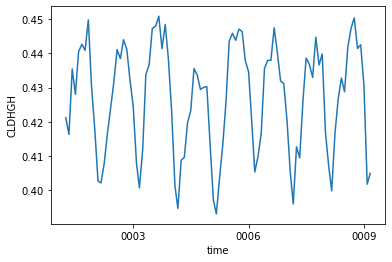

In [15]:
LatWeightAnyVar(CLDHGH_obl0[1].CLDHGH).plot()

In [38]:

#%% define ozone column calculation function

def O3_col(ds, time = False, O2_mr = 0.21, lon = True):
    
    g = 9.80616           # gravity acceleration (cm/sec2)
    
    to_DU = 1./2.6867e20  # convert colunm density / cm^2 to Dobson units
    
    N2_mr = 1-O2_mr       # nitrogen mixing ratio
    
    m_avg = ((28*N2_mr)+(O2_mr*32))*1.661e-27 
                          # average weight of atmosphere
                          # calcualte column integrals 
    O3 = ds['O3']         # variables to calcualate hybrid pressure on model interfaces
    ps = ds['PS'].values  # surface pressure
    p0 = ds['P0'].values
    hyai = ds['hyai'].values
    hybi = ds['hybi'].values
    dp = np.ndarray(O3.shape, np.float32)
    
    nt = 1
    try:
        nt = ds['time'].size
    except:
        nt = 0
        
    ny = ds['lat'].size
    nz = ds['lev'].size
    nx = ds['lon'].size
    press = np.ndarray(nz, np.float32)

    
    if (nt > 0):
        for i in range(nt):
            for j in range(ny):
                for k in range(nx):
                    press = hyai * p0 + hybi * ps[i,j,k]
                    for iz in range(nz):
                        dp[i,iz,j,k] = (press[iz+1]-press[iz]) 
    else:
        for j in range(ny):
            for k in range(nx):
                press = hyai * p0 + hybi * ps[j,k]
                for iz in range(nz):
                    dp[iz,j,k] = (press[iz+1]-press[iz])
                    
    #calcualte column integrals 
    O3_mid = O3 * dp / (m_avg*g)

#     if (nt > 0):
#         for i in range(nt):
#             for j in range(96):
#                 for k in range(144):
#                     o3[i,:,j,k] = o3[i,:,j,k]/g    # -> mol cm^-2
#     else:
#         for j in range(96):
#             for k in range(144):
#                 o3[:,j,k] = o3[:,j,k]/g
    
    o3col = np.sum(O3_mid, axis = 1) * to_DU           # convert to DU
                                                   # integrate by summing small chunks
    if (lon == False):
        
        o3col  = o3col.mean(dim='lon')
        
    if (time == False):
        
        try:
            o3col  = o3col.mean(dim='time')
        except:
            o3col  = o3col
    print('O3 columns calculated')
    return o3col


In [17]:
lat  = H2O_obl0[4]['lat']
lev  = H2O_obl0[4]['lev']
lon  = H2O_obl0[4]['lon']
H2O  = H2O_obl0[4]['H2O']  
ps   = H2O_obl0[4]['PS'].values
p0   = H2O_obl0[4]['P0'].values
hyai = H2O_obl0[4]['hyai'].values
hybi = H2O_obl0[4]['hybi'].values

nt = H2O_obl0[4]['time'].size
ny = H2O_obl0[4]['lat'].size
nz = H2O_obl0[4]['lev'].size
nx = H2O_obl0[4]['lon'].size

press = np.ndarray(nz, np.float32)
dp = np.ndarray(H2O.shape, np.float32)


In [18]:
for i in range(nt):  # at some time
    for j in range(ny): # at some location
        for k in range(nx):
            press = hyai * p0 + hybi * ps[i,j,k] # ps surface pressure at a point
            for iz in range(nz):# at some height, define dp 
                dp[i,iz,j,k] = (press[iz+1]-press[iz]) 

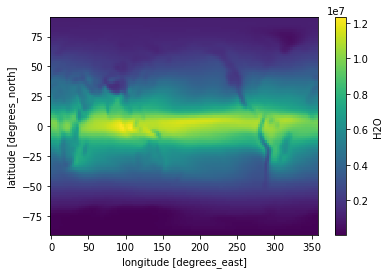

In [19]:
g = 9.8061
O2_mr = 0.21
N2_mr = 1-O2_mr
m_avg = ((28*N2_mr)+(O2_mr*32))*1.661*10**(-27)

H2O = H2O * dp / (m_avg*g) # if you give 'g' here, every grid cell will be scaled down by g 

to_DU  = 1./2.6867e20

H2Ocol = np.sum(H2O, axis = 1) * to_DU
H2Ocol = H2Ocol.mean(dim='time')

H2Ocol.plot()

In [20]:
lat_O3  = O3_obl0[4]['lat']
lev_O3  = O3_obl0[4]['lev']
lon_O3  = O3_obl0[4]['lon']
O3  = O3_obl0[4]['O3']  
ps_O3   = O3_obl0[4]['PS'].values
p0_O3   = O3_obl0[4]['P0'].values
hyai_O3 = O3_obl0[4]['hyai'].values
hybi_O3 = O3_obl0[4]['hybi'].values

nt_O3 = O3_obl0[4]['time'].size
ny_O3 = O3_obl0[4]['lat'].size
nz_O3 = O3_obl0[4]['lev'].size
nx_O3 = O3_obl0[4]['lon'].size

press_O3 = np.ndarray(nz, np.float32)
dp_O3 = np.ndarray(O3.shape, np.float32)

In [21]:
for i in range(nt_O3):
    for j in range(ny_O3):
        for k in range(nx_O3):
            press_O3 = hyai_O3 * p0_O3 + hybi_O3 * ps_O3[i,j,k] # surface pressure at a point
            for iz in range(nz_O3):
                dp_O3[i,iz,j,k] = (press_O3[iz+1]-press_O3[iz]) 

In [22]:
g = 9.8061
O2_mr = 0.21
N2_mr = 1-O2_mr
m_avg = ((28*N2_mr)+(O2_mr*32))*1.661*10**(-27)
O3 = O3 * dp_O3 / (m_avg*g)  

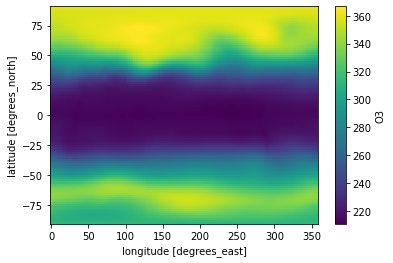

In [23]:
to_DU = 1./2.6867e20
O3col = np.sum(O3, axis = 1) * to_DU
O3col  = O3col.mean(dim='time').plot()

In [ ]:
O3_col=O3_col(O3_obl0[4], time = False, O2_mr = 0.21, lon = True)

O3 columns calculated


In [37]:
O3_col

<xarray.DataArray 'O3' (lev: 70, lat: 96, lon: 144)>
dask.array<mul, shape=(70, 96, 144), dtype=float32, chunksize=(70, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lev      (lev) float64 5.96e-06 9.827e-06 1.62e-05 ... 957.5 976.3 992.6